<a href="https://colab.research.google.com/github/jonathancagua/audio/blob/main/audio_cuanti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Este conjunto de datos recopila cantos de cinco especies de aves (Cucarachero de Bewick, Cardenal Norteño, Robin Americano, Gorrión Melódico y Cenzontle Norteño) con el objetivo de entrenar modelos de identificación a partir de grabaciones de 3 segundos. Los audios, extraídos de la plataforma xeno-canto, están estandarizados en formato wav (22050 Hz, mono) y se incluyen en un archivo CSV con metadatos asociados. Puede explorar el conjunto de datos completo en [Kaggle](
https://www.kaggle.com/datasets/vinayshanbhag/bird-song-data-set)

In [1]:
import pandas as pd
import numpy as np
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import librosa.display
from sklearn.model_selection import train_test_split
import keras
from keras import Model, Input
from keras.layers import Conv1D, Flatten, Dense, Dropout, SpatialDropout1D, GlobalAveragePooling1D
from keras.optimizers import Adam
from keras.optimizers.schedules import ExponentialDecay
from keras.losses import SparseCategoricalCrossentropy
from keras.metrics import SparseCategoricalAccuracy
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
from keras.callbacks import TensorBoard, ModelCheckpoint
import seaborn as sns

In [2]:
!pip install kaggle

In [3]:
!kaggle datasets download -d vinayshanbhag/bird-song-data-set --unzip -p ./bird-data



Dataset URL: https://www.kaggle.com/datasets/vinayshanbhag/bird-song-data-set
License(s): other
100% 2.09G/2.09G [00:51<00:00, 43.4MB/s]



In [4]:
import os

DATA_DIR = "/content/bird-data"
metadata = pd.read_csv(f"{DATA_DIR}/bird_songs_metadata.csv")

label_dict = {
    'bewickii': 0, 'polyglottos': 1, 'migratorius': 2,
    'melodia': 3, 'cardinalis': 4
}
bird_labels = metadata['species'].map(label_dict).values

bird_filepaths = (DATA_DIR + "/wavfiles/" + metadata['filename']).values

bird_filepaths_train, bird_filepaths_val, bird_labels_train, bird_labels_val = train_test_split(
    bird_filepaths, bird_labels, test_size=0.10, random_state=2419
)


In [5]:
# Constantes globales de preprocesado
SR = 22050
DURATION = 3
NUM_SAMPLES = SR * DURATION  # 66150

FRAME_LENGTH = 512
FRAME_STEP = 64

TIME_FRAMES = 1026
FREQ_BINS = 257


def load_audio_fixed(path):
    # Carga robusta: WAV mono + SR fijo + longitud fija
    path_bytes = path.numpy()
    path_string = path_bytes.decode('utf-8') if isinstance(path_bytes, (bytes, bytearray)) else str(path_bytes)

    try:
        y, _ = librosa.load(path_string, sr=SR, mono=True)
    except Exception:
        # Si falla la lectura, devolvemos silencio para no romper el pipeline
        y = np.zeros((0,), dtype=np.float32)

    if y.shape[0] > NUM_SAMPLES:
        y = y[:NUM_SAMPLES]
    elif y.shape[0] < NUM_SAMPLES:
        y = np.pad(y, (0, NUM_SAMPLES - y.shape[0]), mode='constant')

    return y.astype(np.float32)


def map_function_fixed(path_tensor, label):
    y = tf.py_function(load_audio_fixed, [path_tensor], tf.float32)
    y.set_shape([NUM_SAMPLES])

    # 1. STFT (shape fijo por longitud fija de audio)
    stft = tf.signal.stft(
        y,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=FRAME_LENGTH,
        pad_end=False
    )
    spectrogram = tf.abs(stft)

    # 2. dB con logaritmo base 10 (misma lógica actual)
    log10_spec = tf.math.log(spectrogram + 1e-6) / tf.math.log(10.0)
    spectrogram_db = 20.0 * log10_spec - 20.0 * (tf.math.log(100.0) / tf.math.log(10.0))

    # 3. Normalización a rango [0, 1]
    spectrogram_norm = (spectrogram_db + 80.0) / 80.0
    spectrogram_norm = tf.clip_by_value(spectrogram_norm, 0.0, 1.0)
    spectrogram_norm.set_shape([TIME_FRAMES, FREQ_BINS])

    return spectrogram_norm, label


def map_function_fixed_4d(path_tensor, label):
    # Variante para exportación futura (canal al final)
    spectrogram_norm, label = map_function_fixed(path_tensor, label)
    spectrogram_norm = tf.expand_dims(spectrogram_norm, axis=-1)
    spectrogram_norm.set_shape([TIME_FRAMES, FREQ_BINS, 1])
    return spectrogram_norm, label


In [6]:
def make_dataset(labels, filepaths, shuffle=False, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(filepaths))

    dataset = dataset.map(map_function_fixed, num_parallel_calls=tf.data.AUTOTUNE)

    dataset = dataset.batch(batch_size, drop_remainder=True)

    return dataset.prefetch(tf.data.AUTOTUNE)


In [7]:
dataset_train = make_dataset(bird_labels_train, bird_filepaths_train, shuffle=True)
dataset_val = make_dataset(bird_labels_val, bird_filepaths_val, shuffle=False)


Shape batch espectrograma (train): (32, 1026, 257)
Shape batch labels (train): (32,)
Shape espectrograma 4D (1 muestra): (1026, 257, 1)


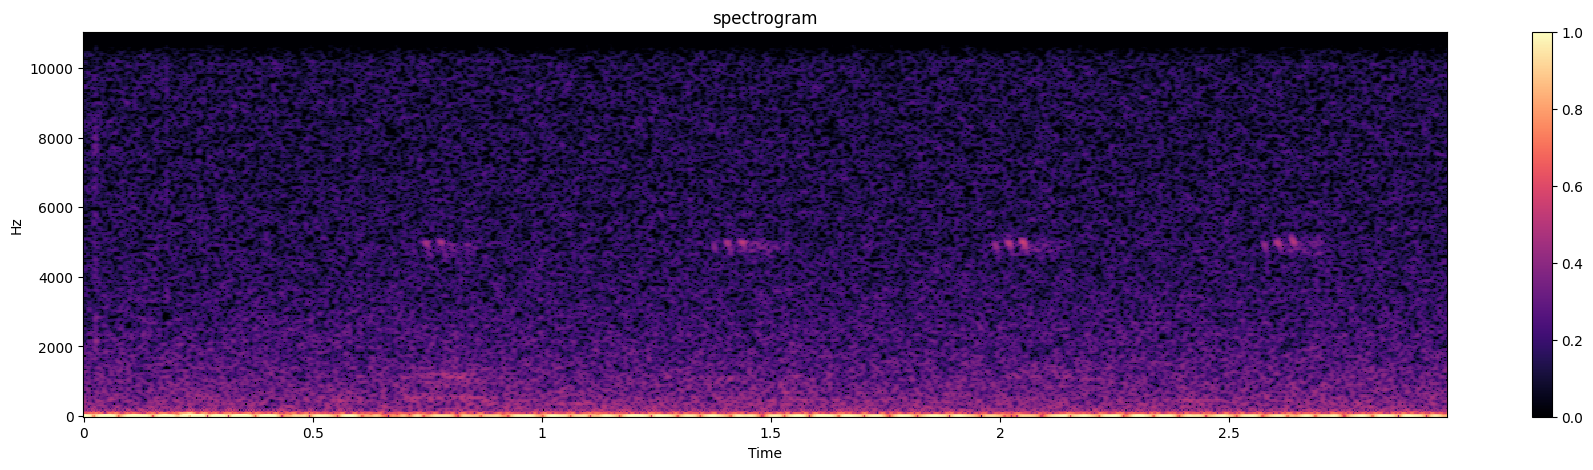

In [8]:
for spectrograms, labels in dataset_train.take(1):
    print('Shape batch espectrograma (train):', spectrograms.shape)
    print('Shape batch labels (train):', labels.shape)

    spec_4d, _ = map_function_fixed_4d(
        tf.constant(bird_filepaths_train[0]),
        tf.constant(bird_labels_train[0])
    )
    print('Shape espectrograma 4D (1 muestra):', spec_4d.shape)

    plt.figure(figsize=(22, 5))
    librosa.display.specshow(
        spectrograms[0].numpy().T,
        sr=22050,
        hop_length=64,
        n_fft=512,
        y_axis='linear',
        x_axis='time',
        cmap='magma'
    )
    plt.colorbar()
    plt.title('spectrogram')
    plt.show()

In [9]:
from keras import Model, Input
from keras.layers import Conv1D, Flatten, Dense, Dropout, SpatialDropout1D, GlobalAveragePooling1D, BatchNormalization

def create_model():
    inputs = Input(shape=(TIME_FRAMES, FREQ_BINS), name='0_Input_shape')

    # Bloque 1
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='1_Conv1D')(inputs)
    x = BatchNormalization()(x) # Agregado: Estabiliza el entrenamiento
    x = SpatialDropout1D(0.17, name='2_SpatialDropout1D')(x)

    # Bloque 2
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='3_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='4_SpatialDropout1D')(x)

    # Bloque 3
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='5_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='6_SpatialDropout1D')(x)

    # Bloque 4
    x = Conv1D(128, kernel_size=8, strides=2, activation='relu', padding='same', name='7_Conv1d')(x)
    x = BatchNormalization()(x)
    x = SpatialDropout1D(0.17, name='8_SpatialDropout1D')(x)

    # Reducción y Clasificación
    x = GlobalAveragePooling1D(name='9_Global_avg_pooling')(x)
    x = Dense(512, activation='relu', name='10_Dense')(x)
    x = Dropout(0.5, name='11_Dropout')(x)

    # activation='softmax'
    outputs = Dense(5, activation='softmax', name='12_Output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='Bird_audio_classification_model')
    return model


In [10]:
# Instanciar y compilar
model = create_model()
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "Bird_audio_classification_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 0_Input_shape (InputLayer)      │ (None, 1026, 257)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1_Conv1D (Conv1D)               │ (None, 513, 128)       │       263,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 513, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2_SpatialDropout1D              │ (None, 513, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3_Conv1d (Conv1D)               │ (None, 257, 128)       │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 257, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 4_SpatialDropout1D              │ (None, 257, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 5_Conv1d (Conv1D)               │ (None, 129, 128)       │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 129, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 6_SpatialDropout1D              │ (None, 129, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 7_Conv1d (Conv1D)               │ (None, 65, 128)        │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 65, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 8_SpatialDropout1D              │ (None, 65, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 9_Global_avg_pooling            │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 10_Dense (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 11_Dropout (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 12_Output (Dense)               │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 727,557 (2.78 MB)

 Trainable params: 726,533 (2.77 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [12]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, TensorBoard
import os

logdir = 'tb_logs/modelo_final'

checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_pajaros.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

tb_callback = TensorBoard(log_dir=logdir)

history = model.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=50,
    callbacks=[checkpoint, early_stop, tb_callback]
)


Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4089 - loss: 1.3418
Epoch 1: val_accuracy improved from None to 0.44336, saving model to mejor_modelo_pajaros.keras

Epoch 1: finished saving model to mejor_modelo_pajaros.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 40s 199ms/step - accuracy: 0.4751 - loss: 1.2131 - val_accuracy: 0.4434 - val_loss: 1.3872
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.5648 - loss: 1.0397
Epoch 2: val_accuracy improved from 0.44336 to 0.51367, saving model to mejor_modelo_pajaros.keras

Epoch 2: finished saving model to mejor_modelo_pajaros.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 30s 197ms/step - accuracy: 0.5759 - loss: 1.0062 - val_accuracy: 0.5137 - val_loss: 1.3754
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.6138 - loss: 0.9223
Epoch 3: val_accuracy improved from 0.51367 to 0.67578, saving model to mejor_modelo_pajaros.keras

Epoch 3: finished saving model to mejor_modelo_pajaros.keras
152/152 ━━━━━━━━

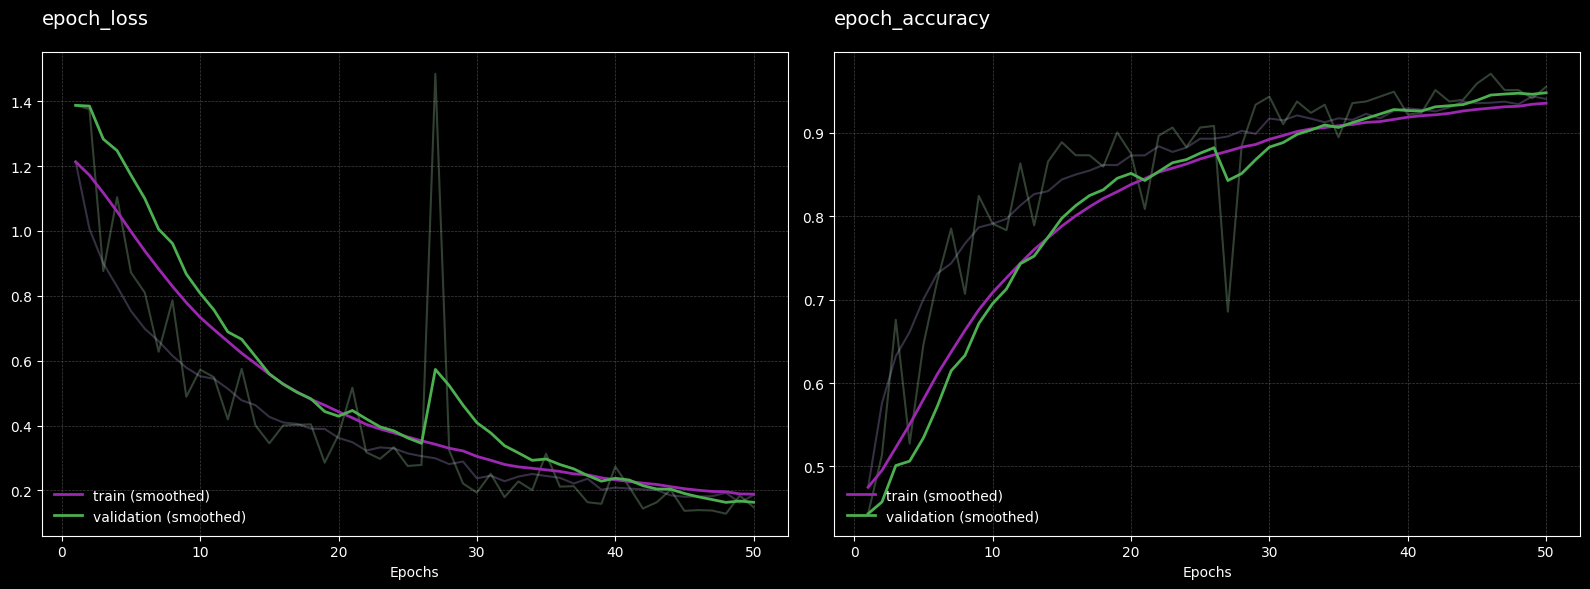

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tensorboard_style(history):
    plt.style.use('dark_background')

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    def smooth_curve(points, factor=0.8):
        smoothed_points = []
        for point in points:
            if smoothed_points:
                previous = smoothed_points[-1]
                smoothed_points.append(previous * factor + point * (1 - factor))
            else:
                smoothed_points.append(point)
        return smoothed_points

    plt.figure(figsize=(16, 6))

    # --- Gráfico de Pérdida (Loss) ---
    plt.subplot(1, 2, 1)
    # Líneas tenues (datos reales)
    plt.plot(epochs, loss, color='#b39ddb', alpha=0.3)
    plt.plot(epochs, val_loss, color='#a5d6a7', alpha=0.3)
    # Líneas gruesas (suavizadas)
    plt.plot(epochs, smooth_curve(loss), color='#9c27b0', label='train (smoothed)', linewidth=2)
    plt.plot(epochs, smooth_curve(val_loss), color='#4caf50', label='validation (smoothed)', linewidth=2)

    plt.title('epoch_loss', loc='left', fontsize=14, pad=20)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(loc='lower left', frameon=False)
    plt.xlabel('Epochs')

    # --- Gráfico de Precisión (Accuracy) ---
    plt.subplot(1, 2, 2)
    # Líneas tenues
    plt.plot(epochs, acc, color='#b39ddb', alpha=0.3)
    plt.plot(epochs, val_acc, color='#a5d6a7', alpha=0.3)
    # Líneas gruesas
    plt.plot(epochs, smooth_curve(acc), color='#9c27b0', label='train (smoothed)', linewidth=2)
    plt.plot(epochs, smooth_curve(val_acc), color='#4caf50', label='validation (smoothed)', linewidth=2)

    plt.title('epoch_accuracy', loc='left', fontsize=14, pad=20)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(loc='lower left', frameon=False)
    plt.xlabel('Epochs')

    plt.tight_layout()
    plt.show()

plot_tensorboard_style(history)



In [22]:
model_eval = tf.keras.models.load_model('mejor_modelo_pajaros.keras')

results = model_eval.evaluate(dataset_val, return_dict=True)

print("\n--- Resultados de la Evaluación ---")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.9707 - loss: 0.1391

--- Resultados de la Evaluación ---
accuracy: 0.9707
loss: 0.1391


In [23]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

bird_names = ['bewickii', 'polyglottos', 'migratorius', 'melodia', 'cardinalis']

print("Generando predicciones...")
y_logits = model_eval.predict(dataset_val)

y_pred = tf.argmax(y_logits, axis=1).numpy()

y_true_list = []
for _, labels in dataset_val:
    y_true_list.extend(labels.numpy())
y_true = np.array(y_true_list)

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred, target_names=bird_names))



Generando predicciones...
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    bewickii       0.99      0.97      0.98        86
 polyglottos       0.98      0.96      0.97       112
 migratorius       0.92      0.98      0.95        88
     melodia       0.98      0.96      0.97       128
  cardinalis       0.97      0.99      0.98        98

    accuracy                           0.97       512
   macro avg       0.97      0.97      0.97       512
weighted avg       0.97      0.97      0.97       512



In [24]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

print("Calculando predicciones...")
y_logits = model_eval.predict(dataset_val)

y_prob = tf.nn.softmax(y_logits, axis=1).numpy()

y_pred = np.argmax(y_logits, axis=1)

y_true_list = []
for _, labels in dataset_val:
    y_true_list.extend(labels.numpy())
y_true = np.array(y_true_list)

f1 = f1_score(y_true, y_pred, average='macro')
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
auc = roc_auc_score(y_true, y_prob, average='macro', multi_class='ovo')

# Imprimir resultados
print("-" * 30)
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC ROC:   {auc:.4f}")
print("-" * 30)



Calculando predicciones...
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step
------------------------------
F1 Score:  0.9704
Precision: 0.9697
Recall:    0.9715
AUC ROC:   0.9966
------------------------------


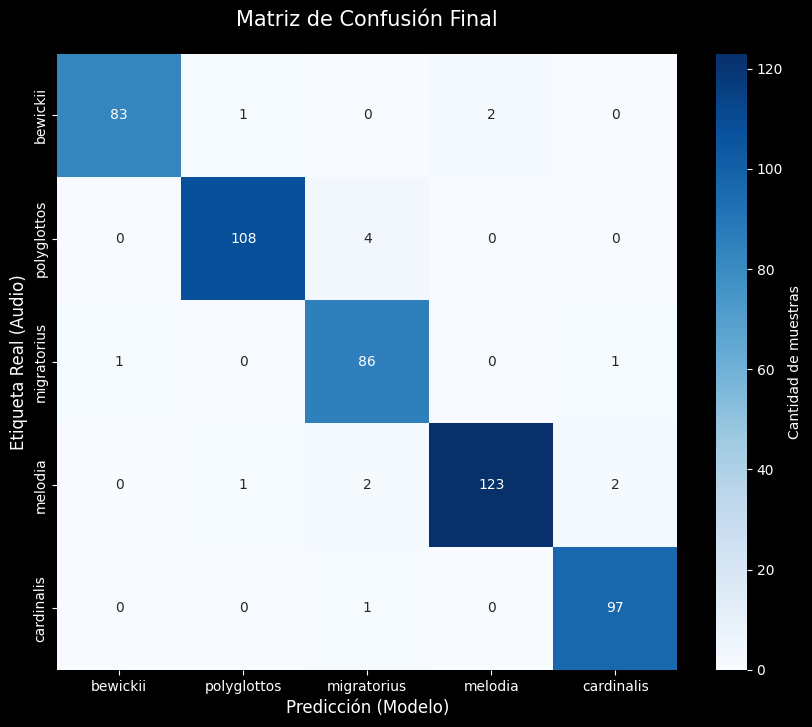

In [25]:
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

confusion_mtx = tf.math.confusion_matrix(y_true, y_pred).numpy()

bird_names = ['bewickii', 'polyglottos', 'migratorius', 'melodia', 'cardinalis']

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx,
            xticklabels=bird_names,
            yticklabels=bird_names,
            annot=True,
            fmt='g',
            cmap='Blues', # O 'magma' si quieres el estilo de antes
            cbar_kws={'label': 'Cantidad de muestras'})

plt.title('Matriz de Confusión Final', fontsize=15, pad=20)
plt.xlabel('Predicción (Modelo)', fontsize=12)
plt.ylabel('Etiqueta Real (Audio)', fontsize=12)
plt.show()


In [26]:
!pip -q install tensorflow-model-optimization

In [27]:
import os
import time
import tempfile
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import tensorflow_model_optimization as tfmot

In [40]:
def collect_y_true(dataset):
    y_true = []
    for _, y in dataset:
        y_true.extend(y.numpy())
    return np.array(y_true)

def get_keras_model_size_mb(model):
    with tempfile.NamedTemporaryFile(suffix=".keras", delete=False) as tmp:
        tmp_path = tmp.name
    model.save(tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    return size_mb

def representative_data_gen():
    # Usa muestras reales del pipeline ya preprocesado
    for x, _ in dataset_train.unbatch().take(100):
        x = tf.expand_dims(x, axis=0)
        yield [tf.cast(x, tf.float32)]

def evaluate_keras_model(model, dataset, model_name="keras_fp32"):
    y_true = collect_y_true(dataset)

    t0 = time.perf_counter()
    y_prob = model.predict(dataset, verbose=0)
    elapsed = time.perf_counter() - t0

    y_pred = np.argmax(y_prob, axis=1)

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
        "auc_ovo_macro": roc_auc_score(y_true, y_prob, average="macro", multi_class="ovo"),
        "size_mb": get_keras_model_size_mb(model),
        "latency_total_s": elapsed,
        "latency_per_sample_ms": (elapsed / len(y_true)) * 1000
    }

def convert_to_tflite(keras_model, quant_mode="dynamic"):
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)

    if quant_mode == "dynamic":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]

    elif quant_mode == "float16":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]

    elif quant_mode == "int8":
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_data_gen
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8

    else:
        raise ValueError(f"Modo no soportado: {quant_mode}")

    return converter.convert()


def evaluate_tflite_model(tflite_model, dataset, model_name):
    import time
    import numpy as np
    import tensorflow as tf
    from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, precision_score, recall_score

    try:
        from ai_edge_litert.interpreter import Interpreter
        interpreter = Interpreter(model_content=tflite_model)
    except ImportError:
        interpreter = tf.lite.Interpreter(model_content=tflite_model)

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    in_detail = input_details[0]
    out_detail = output_details[0]

    in_dtype = in_detail["dtype"]
    out_dtype = out_detail["dtype"]

    # TFLite recomienda quantization_parameters; tomamos el primer scale/zero_point
    in_qparams = in_detail.get("quantization_parameters", {})
    out_qparams = out_detail.get("quantization_parameters", {})

    in_scales = in_qparams.get("scales", [])
    in_zero_points = in_qparams.get("zero_points", [])
    out_scales = out_qparams.get("scales", [])
    out_zero_points = out_qparams.get("zero_points", [])

    in_scale = float(in_scales[0]) if len(in_scales) else 1.0
    in_zero = int(in_zero_points[0]) if len(in_zero_points) else 0

    out_scale = float(out_scales[0]) if len(out_scales) else 1.0
    out_zero = int(out_zero_points[0]) if len(out_zero_points) else 0

    all_preds = []
    all_labels = []

    t0 = time.perf_counter()

    for images, labels in dataset:
        imgs_np = images.numpy() if hasattr(images, "numpy") else np.asarray(images)
        lbls_np = labels.numpy() if hasattr(labels, "numpy") else np.asarray(labels)

        for i in range(len(imgs_np)):
            x = np.expand_dims(imgs_np[i], axis=0).astype(np.float32)

            # Cuantizar entrada solo si el modelo lo requiere
            if in_dtype == np.int8:
                x = np.round(x / in_scale + in_zero)
                x = np.clip(x, -128, 127).astype(np.int8)
            elif in_dtype == np.uint8:
                x = np.round(x / in_scale + in_zero)
                x = np.clip(x, 0, 255).astype(np.uint8)
            else:
                x = x.astype(in_dtype)

            interpreter.set_tensor(in_detail["index"], x)
            interpreter.invoke()

            y = interpreter.get_tensor(out_detail["index"])

            # Descuantizar salida si hace falta
            if out_dtype == np.int8:
                y = (y.astype(np.float32) - out_zero) * out_scale
            elif out_dtype == np.uint8:
                y = (y.astype(np.float32) - out_zero) * out_scale
            else:
                y = y.astype(np.float32)

            all_preds.append(y.flatten())
            all_labels.append(lbls_np[i])

    elapsed = time.perf_counter() - t0

    all_preds = np.vstack(all_preds).astype(np.float64)
    all_labels = np.array(all_labels)

    # Si las salidas no parecen probabilidades, aplicar softmax
    row_sums = all_preds.sum(axis=1, keepdims=True)
    if np.any(all_preds < 0) or not np.allclose(row_sums, 1.0, atol=1e-3):
        exp_preds = np.exp(all_preds - np.max(all_preds, axis=1, keepdims=True))
        all_preds = exp_preds / np.sum(exp_preds, axis=1, keepdims=True)

    # Etiquetas: soporta sparse o one-hot
    if all_labels.ndim > 1:
        y_true_labels = np.argmax(all_labels, axis=1)
        y_true_auc = all_labels
    else:
        y_true_labels = all_labels
        num_classes = all_preds.shape[1]
        y_true_auc = np.eye(num_classes)[y_true_labels]

    y_pred_labels = np.argmax(all_preds, axis=1)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true_labels, y_pred_labels),
        "f1_macro": f1_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true_labels, y_pred_labels, average="macro", zero_division=0),
        "size_kb": len(tflite_model) / 1024,
        "latency_total_s": elapsed,
        "latency_per_sample_ms": (elapsed / len(y_true_labels)) * 1000
    }

    try:
        result["auc_ovo_macro"] = roc_auc_score(
            y_true_auc, all_preds, average="macro", multi_class="ovo"
        )
    except ValueError:
        result["auc_ovo_macro"] = np.nan

    return result




In [41]:
import numpy as np
import pandas as pd

def safe_evaluate_tflite(tflite_model, dataset, model_name):
    """
    Versión robusta de evaluación que normaliza las salidas
    para que sumen 1.0, evitando errores en sklearn.
    """
    return evaluate_tflite_model(tflite_model, dataset, model_name)

results = []

results.append(evaluate_keras_model(model_eval, dataset_val, model_name="baseline_fp32"))

tflite_dynamic = convert_to_tflite(model_eval, quant_mode="dynamic")
results.append(evaluate_tflite_model(tflite_dynamic, dataset_val, model_name="ptq_dynamic"))

tflite_float16 = convert_to_tflite(model_eval, quant_mode="float16")
results.append(evaluate_tflite_model(tflite_float16, dataset_val, model_name="ptq_float16"))

tflite_int8 = convert_to_tflite(model_eval, quant_mode="int8")
results.append(evaluate_tflite_model(tflite_int8, dataset_val, model_name="ptq_int8"))

results_df = pd.DataFrame(results)
display(results_df)


Saved artifact at '/tmp/tmpsfedxfyn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134740564298640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564300368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564300560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564300752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564298832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564301712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564301520

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saved artifact at '/tmp/tmpc9904x9f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134740564298640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564300368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564300560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564300752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564298832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564301712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564301520

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saved artifact at '/tmp/tmpdthjsm84'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1026, 257), dtype=tf.float32, name='0_Input_shape')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  134740564298640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564300368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564299984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564300560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564300752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564298832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564301712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134740564301520

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,model,accuracy,f1_macro,precision_macro,recall_macro,auc_ovo_macro,size_mb,latency_total_s,latency_per_sample_ms,size_kb
0,baseline_fp32,0.970703,0.97037,0.969729,0.971482,0.996699,8.397447,5.152421,10.063323,NaN
1,ptq_dynamic,0.970703,0.97037,0.969729,0.971482,0.996690,NaN,10.250132,20.019788,741.156250
2,ptq_float16,0.970703,0.97037,0.969729,0.971482,0.996696,NaN,10.253481,20.026331,1435.148438
3,ptq_int8,0.962891,0.96229,0.962301,0.962570,0.994806,NaN,6.153337,12.018236,751.531250
